# Setting up Environment

In [244]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# import data
original_df = pd.read_csv('./Automobile_data.csv')
df = original_df.copy()

# Understanding Data
* Displaying inital rows
* Checking data types of each columns
* Count unique values for categorical columns
* Identify constant or near-constant columns
* Check dataset shape and column names. 

In [245]:
# Displaying inital rows
df.head()

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495
1,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500
2,1,?,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500
3,2,164,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.4,10.0,102,5500,24,30,13950
4,2,164,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.4,8.0,115,5500,18,22,17450


In [246]:
df.replace('?', np.nan, inplace=True)

In [247]:
# Checking data types of each columns
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 26 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   symboling          205 non-null    int64  
 1   normalized-losses  164 non-null    object 
 2   make               205 non-null    object 
 3   fuel-type          205 non-null    object 
 4   aspiration         205 non-null    object 
 5   num-of-doors       203 non-null    object 
 6   body-style         205 non-null    object 
 7   drive-wheels       205 non-null    object 
 8   engine-location    205 non-null    object 
 9   wheel-base         205 non-null    float64
 10  length             205 non-null    float64
 11  width              205 non-null    float64
 12  height             205 non-null    float64
 13  curb-weight        205 non-null    int64  
 14  engine-type        205 non-null    object 
 15  num-of-cylinders   205 non-null    object 
 16  engine-size        205 non

In [248]:
# Check dataset shape and column names.
print(f'Dataset Shape: {df.shape}')
print(f'Column Names: {df.columns.tolist()}')

Dataset Shape: (205, 26)
Column Names: ['symboling', 'normalized-losses', 'make', 'fuel-type', 'aspiration', 'num-of-doors', 'body-style', 'drive-wheels', 'engine-location', 'wheel-base', 'length', 'width', 'height', 'curb-weight', 'engine-type', 'num-of-cylinders', 'engine-size', 'fuel-system', 'bore', 'stroke', 'compression-ratio', 'horsepower', 'peak-rpm', 'city-mpg', 'highway-mpg', 'price']


In [249]:
#count unique values for categorical columns
categorical_cols = df.select_dtypes(include=['object']).columns
for col in categorical_cols:
    unique_values = df[col].nunique()
    print(f'Column: {col}, Unique Values: {unique_values}')

Column: normalized-losses, Unique Values: 51
Column: make, Unique Values: 22
Column: fuel-type, Unique Values: 2
Column: aspiration, Unique Values: 2
Column: num-of-doors, Unique Values: 2
Column: body-style, Unique Values: 5
Column: drive-wheels, Unique Values: 3
Column: engine-location, Unique Values: 2
Column: engine-type, Unique Values: 7
Column: num-of-cylinders, Unique Values: 7
Column: fuel-system, Unique Values: 8
Column: bore, Unique Values: 38
Column: stroke, Unique Values: 36
Column: horsepower, Unique Values: 59
Column: peak-rpm, Unique Values: 23
Column: price, Unique Values: 186


In [250]:
# Identify constant or near-constant columns
constant_cols = [col for col in df.columns if df[col].nunique() <= 1]
print(f'Constant or Near-Constant Columns: {constant_cols}')

Constant or Near-Constant Columns: []


In [251]:
# list of columns
columns = df.columns.tolist()
print(columns)

['symboling', 'normalized-losses', 'make', 'fuel-type', 'aspiration', 'num-of-doors', 'body-style', 'drive-wheels', 'engine-location', 'wheel-base', 'length', 'width', 'height', 'curb-weight', 'engine-type', 'num-of-cylinders', 'engine-size', 'fuel-system', 'bore', 'stroke', 'compression-ratio', 'horsepower', 'peak-rpm', 'city-mpg', 'highway-mpg', 'price']


In [252]:
def detect_outlier(col):
   num = pd.to_numeric(col, errors='coerce') # Making sure all the values are numeric.
   q1 = num.quantile(0.25) # calculating first quantile
   q3 = num.quantile(0.75) # calcualting third quantile
   IQR = q3 - q1 # calculating Interquartile range
   lo = q1 - (1.5 * IQR) # calculating lower fence for data, a potential outlier.
   hi = q3 + (1.5 * IQR) # calculating high fence for data, a potential outlier
   outlier = (num < lo) | (num > hi)
   return outlier  # returns boolen value

# Data Cleaning
* Handle Missing Vlaues
* Handle Duplicate records
* Convert data types as necessary
* Normalize categorical values
* Identify and treat outliers

In [253]:
# Check for missing values
missing_values = df.isnull().sum()

for col in df.columns:
    if df[col].isnull().sum() > 0:
        if np.issubdtype(df[col].dtype, np.number):
            df.fillna({col: df[col].median()}, inplace=True)
        else:
            df.fillna({col: df[col].mode()[0]}, inplace=True)

# Verify no missing values remain
print(df.isnull().sum())


symboling            0
normalized-losses    0
make                 0
fuel-type            0
aspiration           0
num-of-doors         0
body-style           0
drive-wheels         0
engine-location      0
wheel-base           0
length               0
width                0
height               0
curb-weight          0
engine-type          0
num-of-cylinders     0
engine-size          0
fuel-system          0
bore                 0
stroke               0
compression-ratio    0
horsepower           0
peak-rpm             0
city-mpg             0
highway-mpg          0
price                0
dtype: int64


In [254]:
# Check for duplicates
duplicates = df.duplicated().sum()
duplicates

np.int64(0)

In [255]:
# Normalize Column Values
Ncategorical_cols = ['make', 'fuel-type', 'aspiration', 'num-of-doors', 'body-style',
                     'drive-wheels', 'engine-location', 'engine-type', 'num-of-cylinders',
                     'fuel-system']
for col in Ncategorical_cols:
    df[col] = (df[col]
               .str.strip()
               .str.lower()
               .str.replace('-', '_')
               .str.replace(' ', '_'))
    
df.head()

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,3,161,alfa_romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495
1,3,161,alfa_romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500
2,1,161,alfa_romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500
3,2,164,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.4,10.0,102,5500,24,30,13950
4,2,164,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.4,8.0,115,5500,18,22,17450


In [256]:
# Removing Outliers in Numerical Columns
numerical_cols = df.select_dtypes(include=[np.number]).columns
for col in numerical_cols:
    outlier = detect_outlier(df[col])  # detecting the outliers row in a given col
    median_value = df[col].median() # calculating median of given value
    df.loc[outlier, col] = median_value # flagging specific row for given column

# Data Integrity
* Confirming that column names and type match expected schema
* Check for missing values and inconsistencies
* Validate referential integrity across tables if applicable
* Ensuring no duplicate rows unless intentional 
* Check for illogical values 

In [257]:
# Conforming that column names and type match expected schema
expected_schema = {
    'symboling': 'int64',
    'normalized-losses': 'float64',
    'make': 'object',
    'fuel-type': 'object',
    'aspiration': 'object',
    'num-of-doors': 'int64',
    'body-style': 'object',
    'drive-wheels': 'object',  
    'engine-location': 'object',
    'wheel-base': 'float64',
    'length': 'float64',
    'width': 'float64',
    'height': 'float64',
    'curb-weight': 'int64',
    'engine-type': 'object',
    'num-of-cylinders': 'int64',
    'engine-size': 'int64',
    'fuel-system': 'object',
    'bore': 'float64',
    'stroke': 'float64',
    'compression-ratio': 'float64',
    'hoursepower': 'float64',
    'peak-rpm': 'float64',
    'city-mpg': 'int64',
    'highway-mpg': 'int64',
    'price': 'float64'
}
for col, expected_type in expected_schema.items():
    if col in df.columns:
        actual_type = str(df[col].dtype)
        if actual_type != expected_type:
            print(f'Column: {col}, Expected Type: {expected_type}, Actual Type: {actual_type}')
    else:
        print(f'Column: {col} is missing from the dataset.')
        


Column: normalized-losses, Expected Type: float64, Actual Type: object
Column: num-of-doors, Expected Type: int64, Actual Type: object
Column: num-of-cylinders, Expected Type: int64, Actual Type: object
Column: bore, Expected Type: float64, Actual Type: object
Column: stroke, Expected Type: float64, Actual Type: object
Column: hoursepower is missing from the dataset.
Column: peak-rpm, Expected Type: float64, Actual Type: object
Column: price, Expected Type: float64, Actual Type: object


## Automated Way to create a expected schema
In the real-world, with larger dataset manually examining the data is not possible. For that, we can take the sample then, start working on it. For expected schema, we can follow following steps:
* Sample the data set
* Initial Schema Inference using panda: this gives the empirical schema, what the data appears to be right now
* Statistical Profiling for Schema Clarity: Because in raw data, column names often doesn't tell the full story. Profiling tells us what they actually contain.
* Validate and Clean Data Types: To ensure each column type reflects its true semantic meaning, not just what pandas guessed. 
* Create the Expected Schema Automatically: This schema becomes the data contract for future validation.
* Verify Remaining Data Against Schema: This ensure all data files conform to my discovered schema - no silent drift or corruption.

In [258]:
inferred_schema = df.convert_dtypes().dtypes   # here convert_dtypes automatically converts columns to best possible dtypes
inferred_schema

symboling                     Int64
normalized-losses    string[python]
make                 string[python]
fuel-type            string[python]
aspiration           string[python]
num-of-doors         string[python]
body-style           string[python]
drive-wheels         string[python]
engine-location      string[python]
wheel-base                  Float64
length                      Float64
width                       Float64
height                      Float64
curb-weight                   Int64
engine-type          string[python]
num-of-cylinders     string[python]
engine-size                   Int64
fuel-system          string[python]
bore                 string[python]
stroke               string[python]
compression-ratio           Float64
horsepower           string[python]
peak-rpm             string[python]
city-mpg                      Int64
highway-mpg                   Int64
price                string[python]
dtype: object

In [259]:
pd.DataFrame({
    'column': df.columns,
    'inferred_dtype': df.dtypes.astype(str).values,
    'better_dtype': inferred_schema.astype(str).values,
    'null_count': df.isnull().sum().values,
    'unique_count': df.nunique().values
})


,column,inferred_dtype,better_dtype,null_count,unique_count
0,symboling,int64,Int64,0,6
1,normalized-losses,object,string,0,51
2,make,object,string,0,22
3,fuel-type,object,string,0,2
4,aspiration,object,string,0,2
5,num-of-doors,object,string,0,2
6,body-style,object,string,0,5
7,drive-wheels,object,string,0,3
8,engine-location,object,string,0,2
9,wheel-base,float64,Float64,0,51


In [260]:

profile = pd.DataFrame({
    'dtype': df.dtypes,
    'null_%': (df.isnull().sum() / len(df)) * 100,
    'unique_count': df.nunique(),
    'example_values': df.head(3).T.values.tolist()  # get first 3 example values for each column, and tolist() to convert to list so arrays can be 1-dimensional
})
profile

,dtype,null_%,unique_count,example_values
symboling,int64,0.0,6,"[3, 3, 1]"
normalized-losses,object,0.0,51,"[161, 161, 161]"
make,object,0.0,22,"[alfa_romero, alfa_romero, alfa_romero]"
fuel-type,object,0.0,2,"[gas, gas, gas]"
aspiration,object,0.0,2,"[std, std, std]"
num-of-doors,object,0.0,2,"[two, two, two]"
body-style,object,0.0,5,"[convertible, convertible, hatchback]"
drive-wheels,object,0.0,3,"[rwd, rwd, rwd]"
engine-location,object,0.0,2,"[front, front, front]"
wheel-base,float64,0.0,51,"[88.6, 88.6, 94.5]"


In [261]:
expected_schema = {
    col: str(dtype) for col, dtype in df.dtypes.items()   # generates expected schema based on current dtypes
}
expected_schema

{'symboling': 'int64',
 'normalized-losses': 'object',
 'make': 'object',
 'fuel-type': 'object',
 'aspiration': 'object',
 'num-of-doors': 'object',
 'body-style': 'object',
 'drive-wheels': 'object',
 'engine-location': 'object',
 'wheel-base': 'float64',
 'length': 'float64',
 'width': 'float64',
 'height': 'float64',
 'curb-weight': 'int64',
 'engine-type': 'object',
 'num-of-cylinders': 'object',
 'engine-size': 'int64',
 'fuel-system': 'object',
 'bore': 'object',
 'stroke': 'object',
 'compression-ratio': 'float64',
 'horsepower': 'object',
 'peak-rpm': 'object',
 'city-mpg': 'int64',
 'highway-mpg': 'int64',
 'price': 'object'}

# Data Cleaning
* Handle Missing Values via imputation or removal
* Handle duplicate records
* Convert data type as necessary
* Normalize categorical values 
* Identify and treat outlier 

In [262]:
# For our given data, we don't have any missing values or duplicates.

# Converting dataype of price from object to float
df['price'] = (
    df['price']
    .astype(str)
    .str.strip()
    .str.replace(r'[^0-9.\-]', '', regex=True)
    .replace('', None)
    .pipe(pd.to_numeric, errors='coerce')
)
# Handling missing values in price column by imputing with median
df['price'].fillna(df['price'].median())

df['price'].isnull().sum()



np.int64(0)

# Univariate Analysis
* Visualize Numeric distributions
* Compute summary statistics 
* Analyze categorical features via bar plots and value counts
* check for skewness and consider transformations.

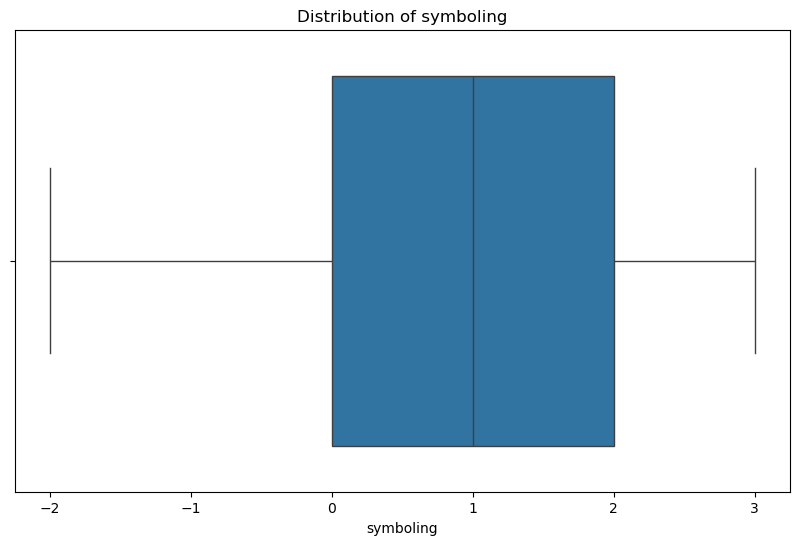

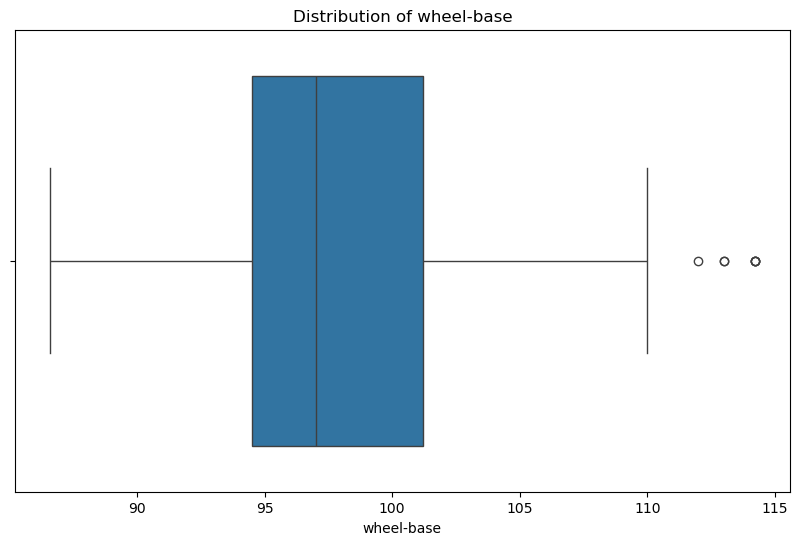

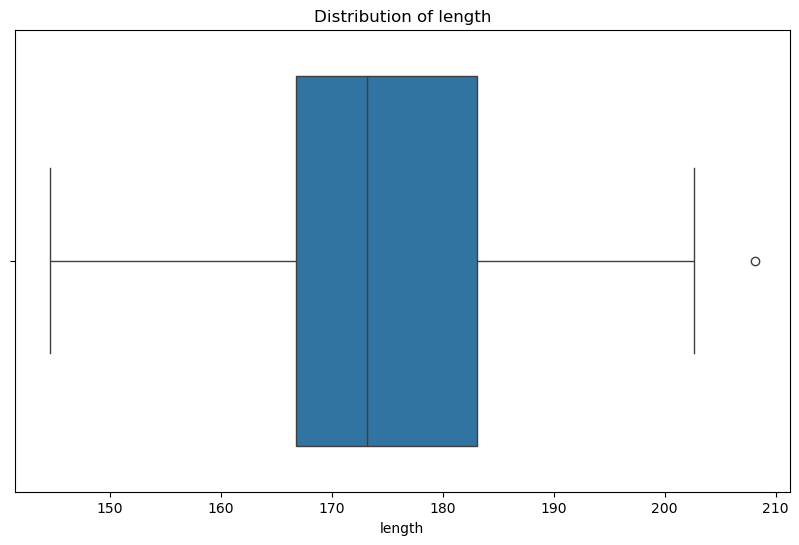

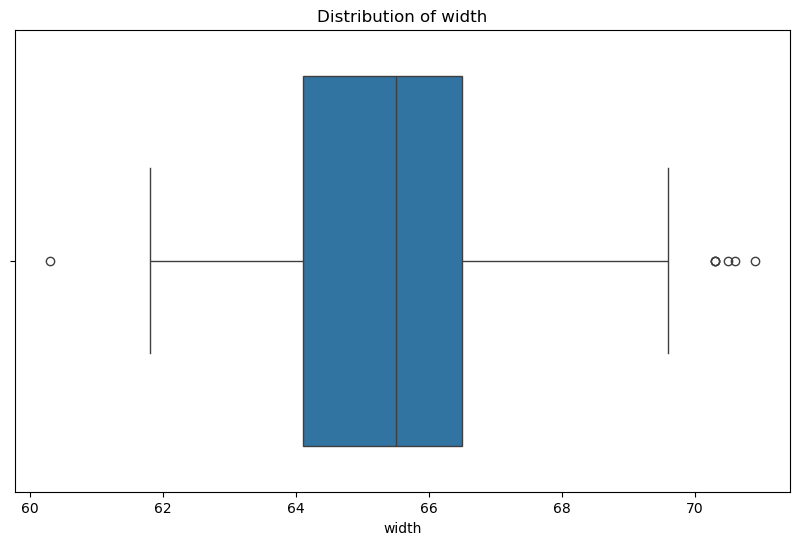

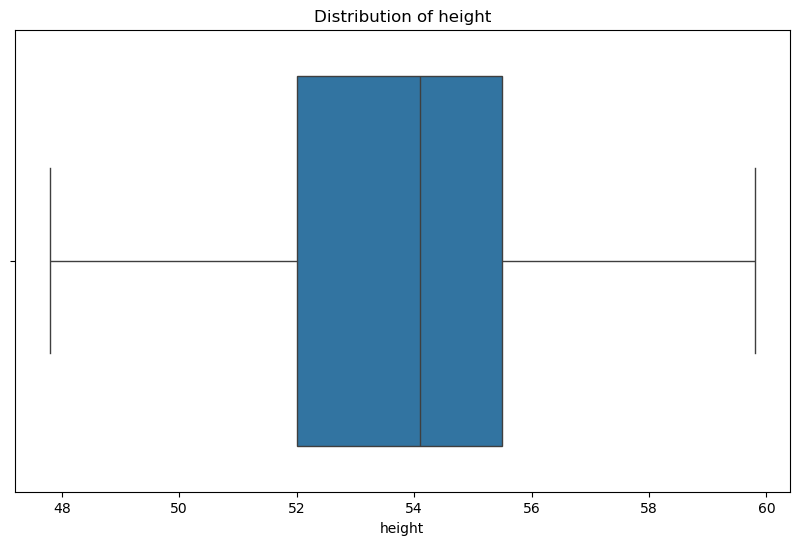

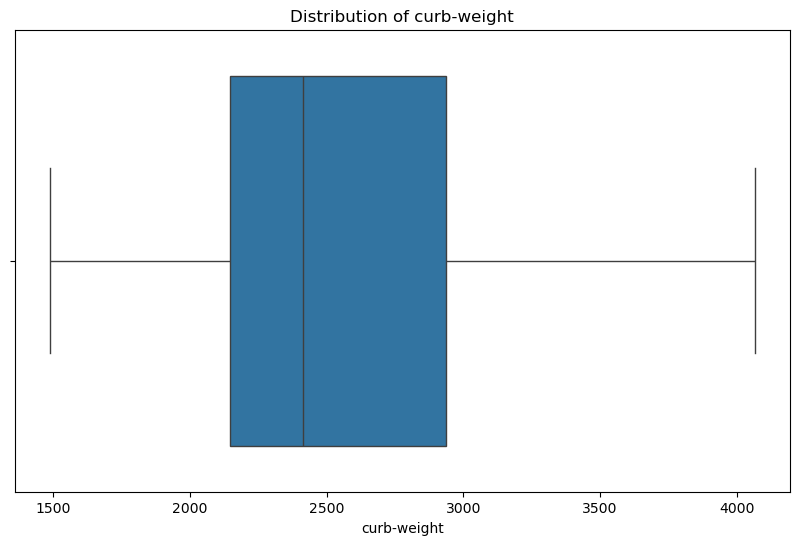

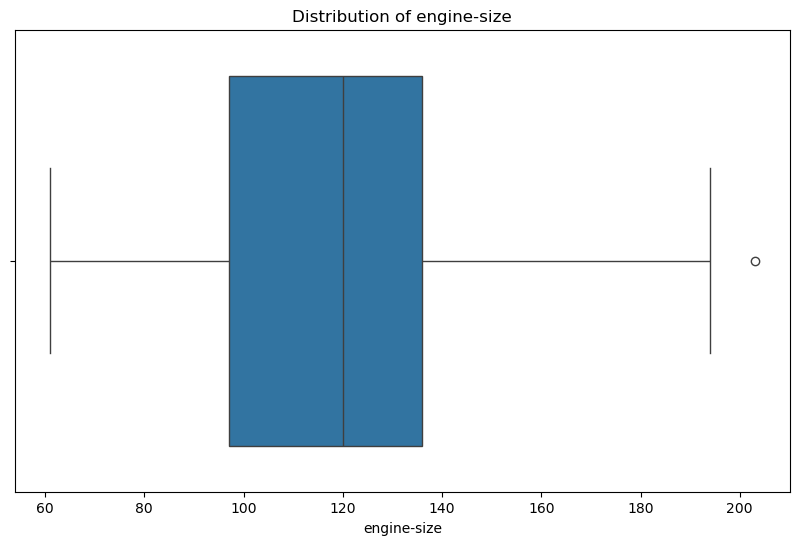

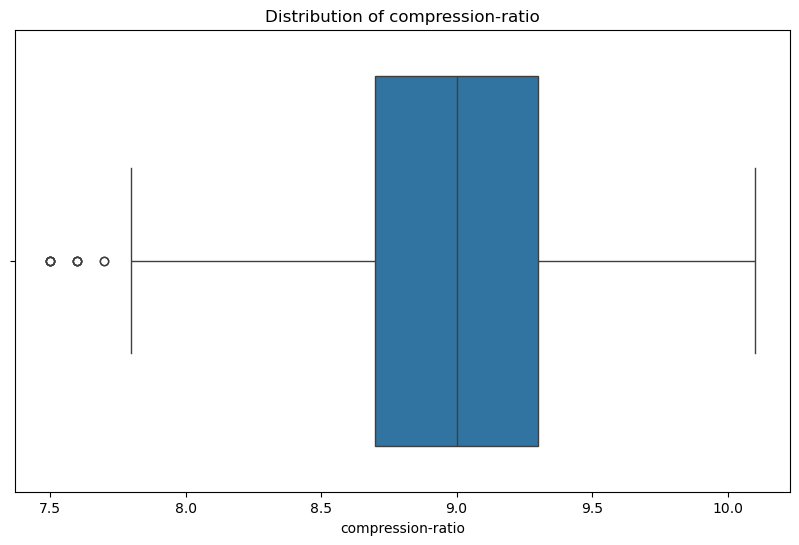

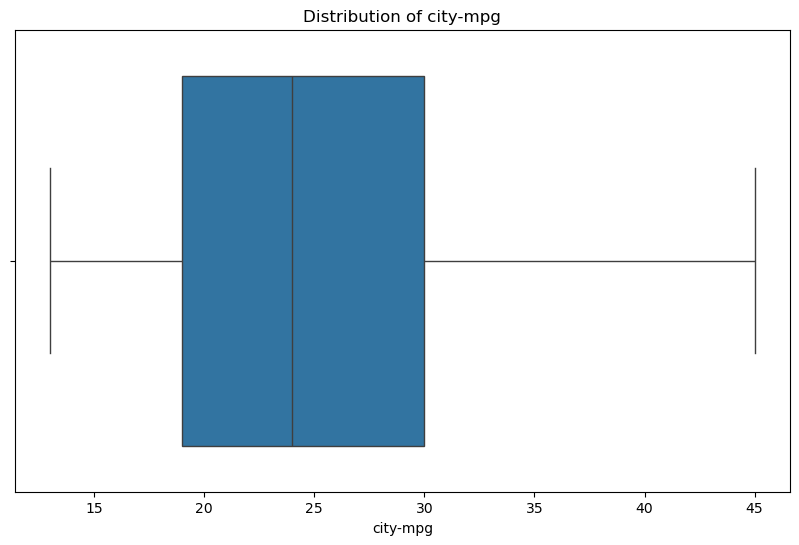

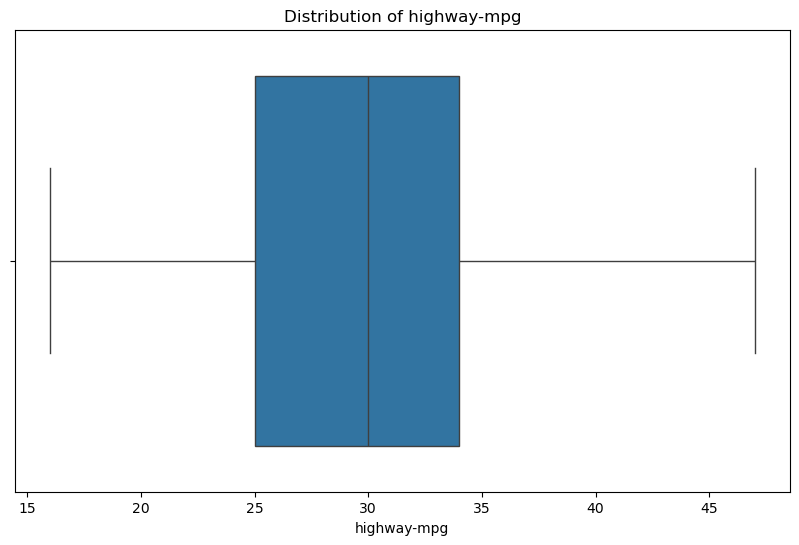

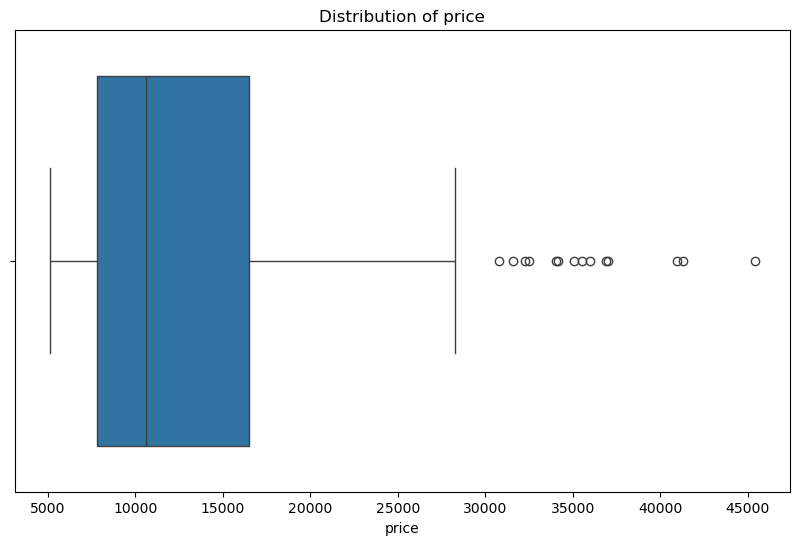

In [263]:
# Visualizing numeric columns
numerical_cols = df.select_dtypes(include=[np.number]).columns
for col in numerical_cols:
    plt.figure(figsize=(10, 6))
    sns.boxplot(data=df, x=col)
    plt.title(f'Distribution of {col}')
    plt.show()



Note: Those small black lines on each blue bar are called error bars. They show how much the data varies for each car brand price (how much prices go up or down from that average).

<Axes: xlabel='width', ylabel='Count'>

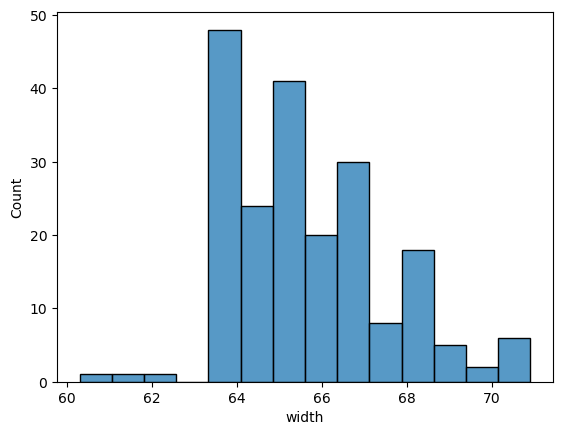

In [264]:
sns.histplot(data=df,  x='width')

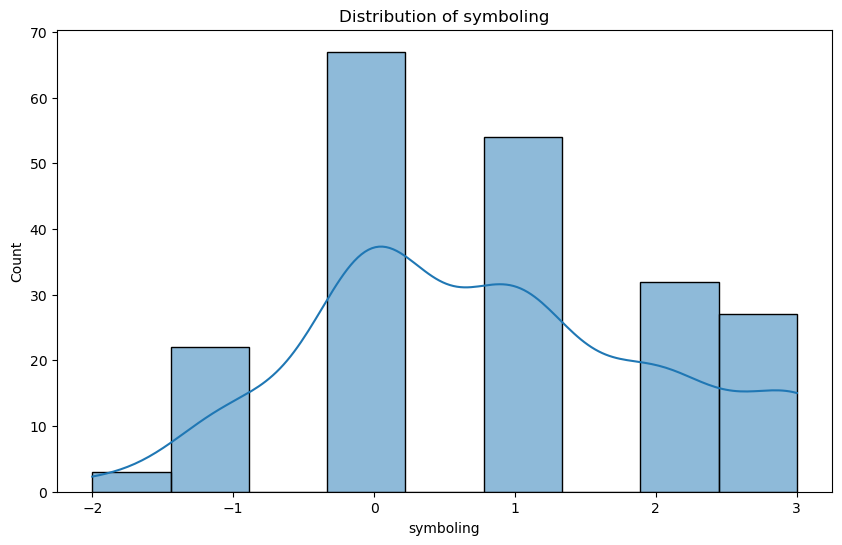

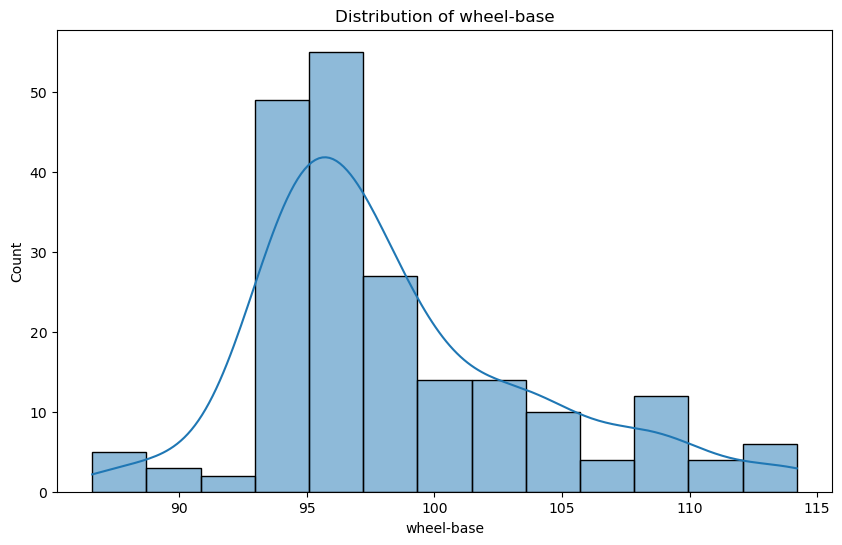

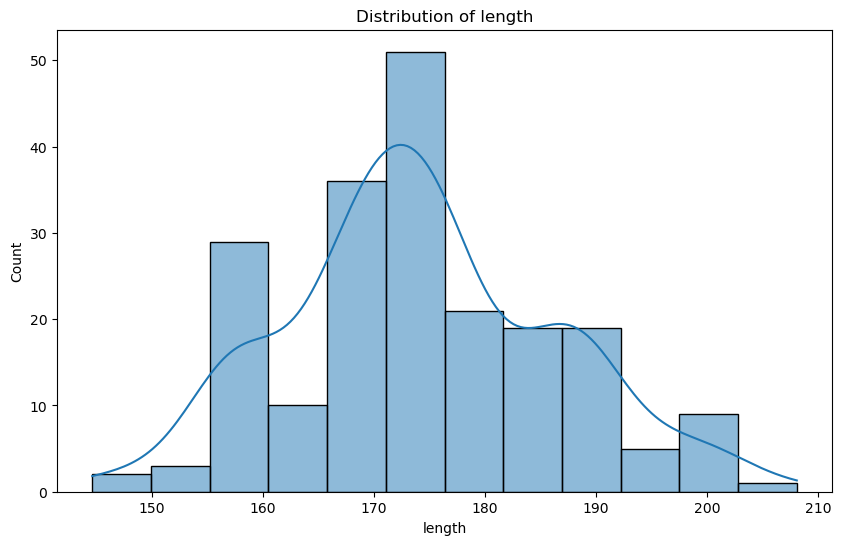

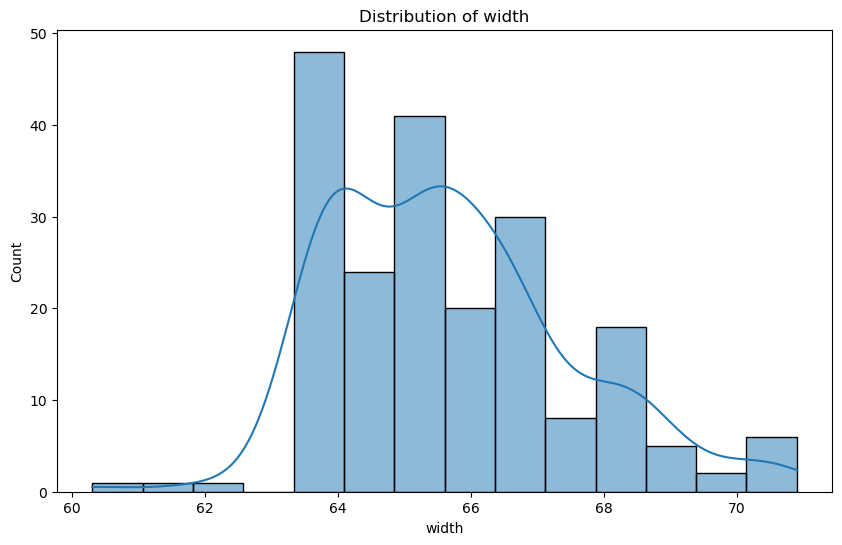

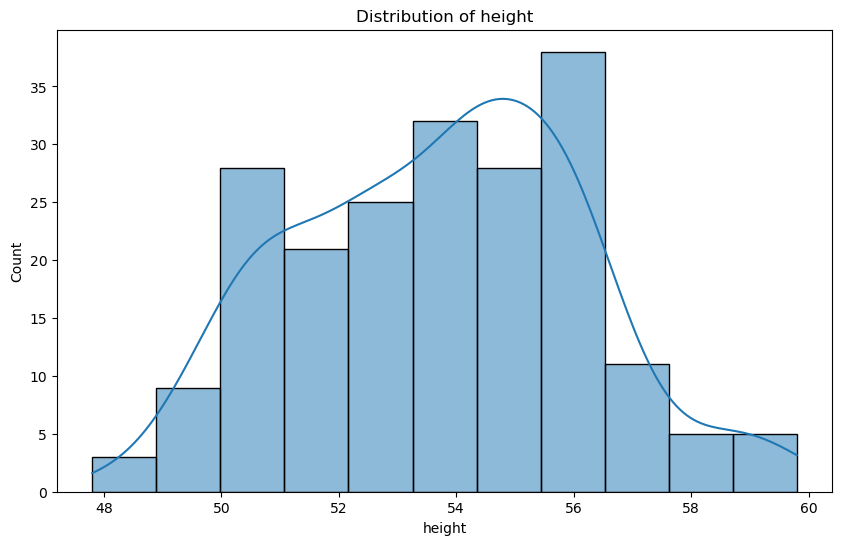

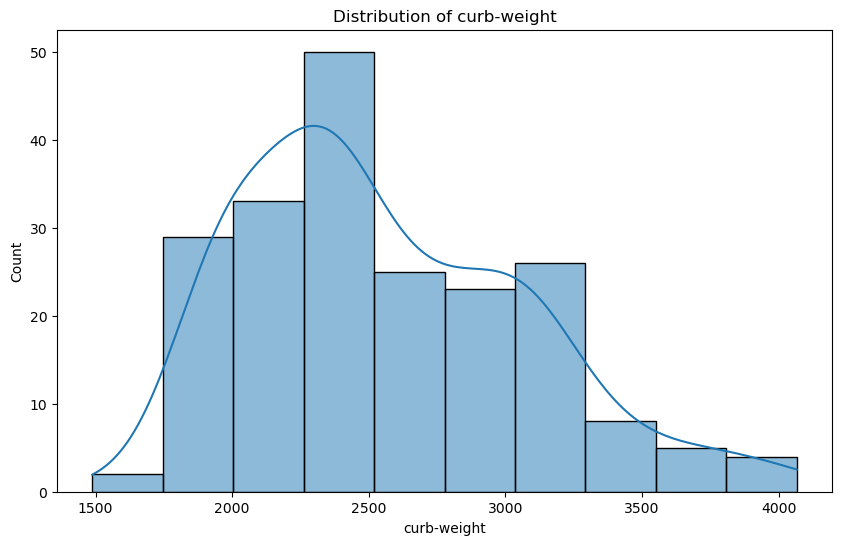

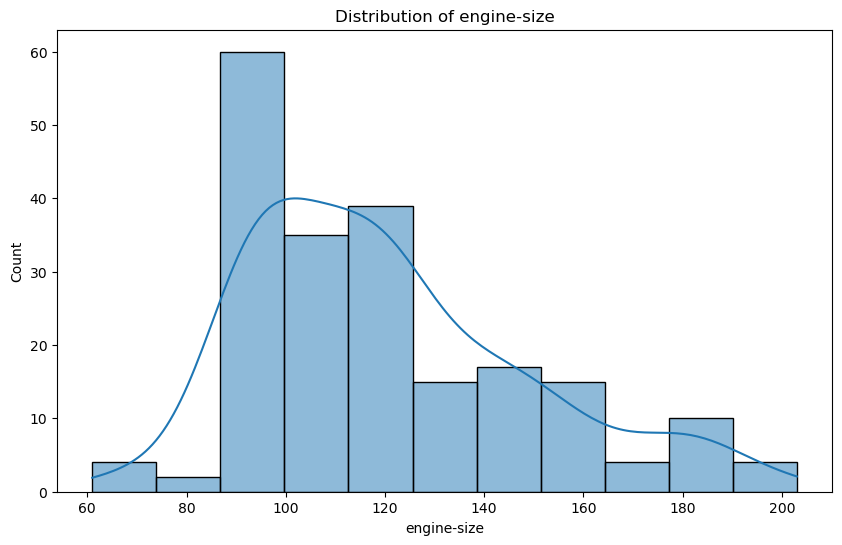

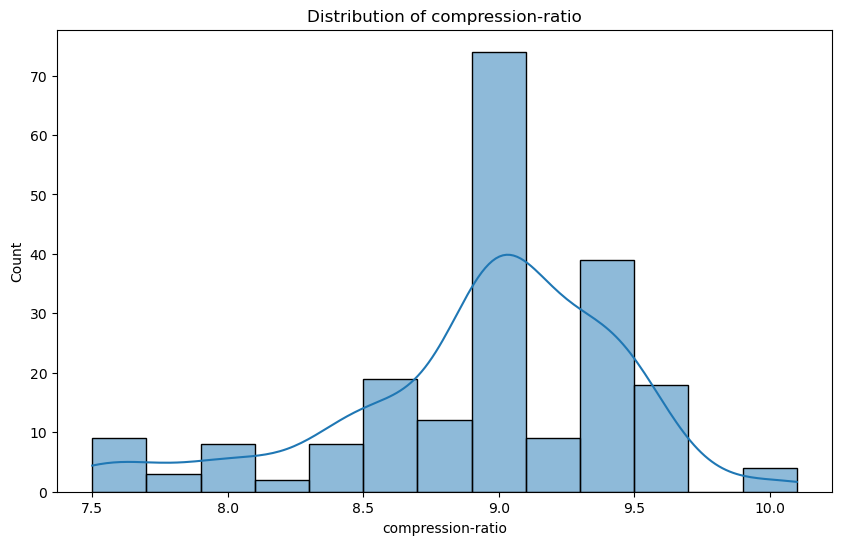

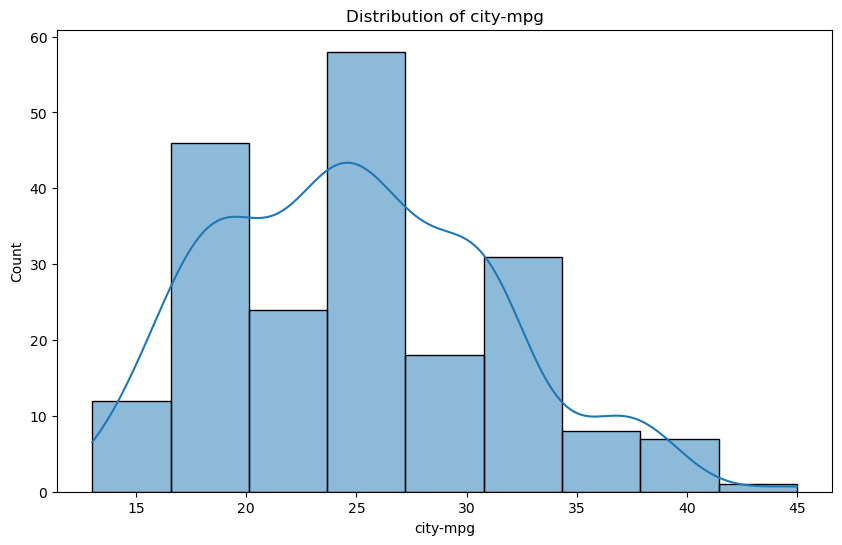

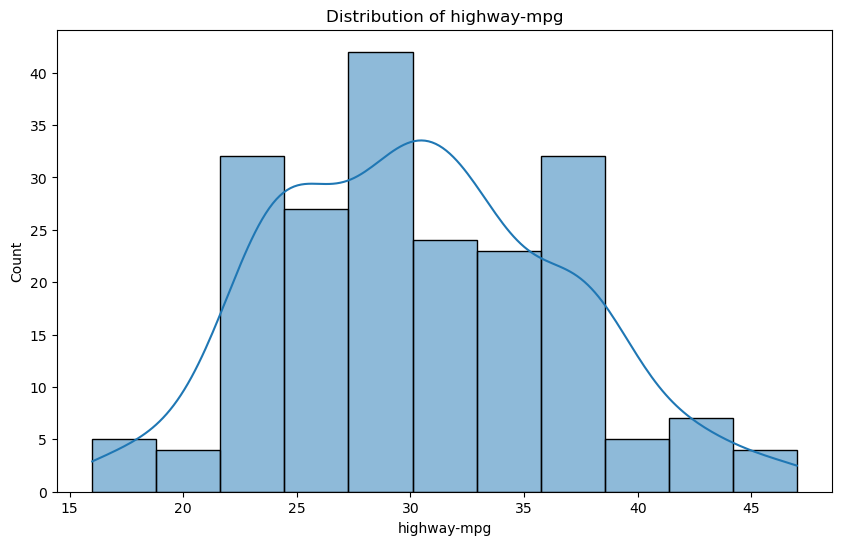

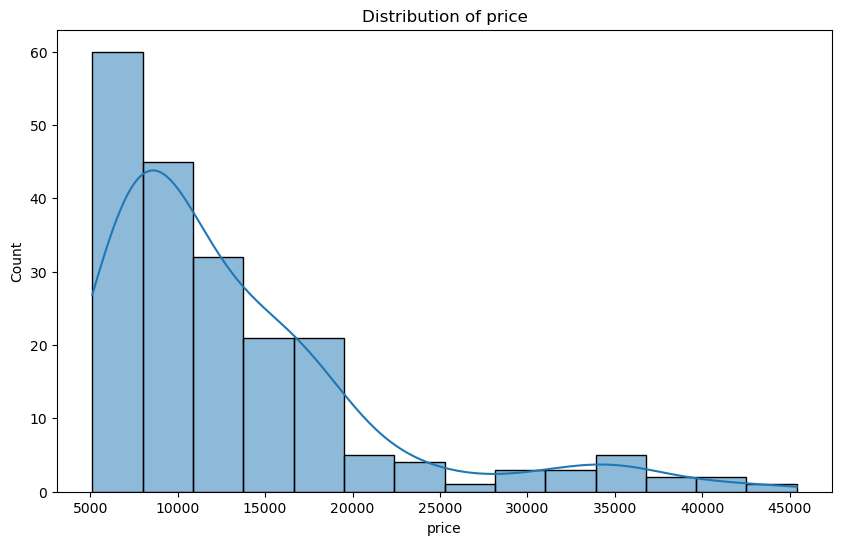

In [265]:
numerical_cols = df.select_dtypes(include=[np.number]).columns
for col in numerical_cols:
    plt.figure(figsize=(10, 6))
    sns.histplot(data=df, x=col, kde=True)
    plt.title(f'Distribution of {col}')
    plt.show()

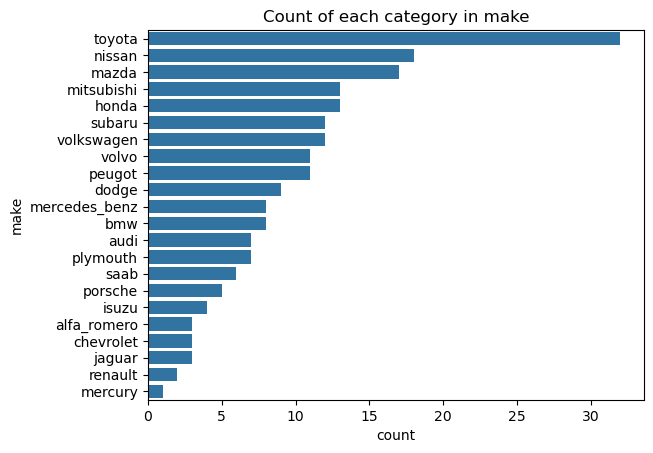

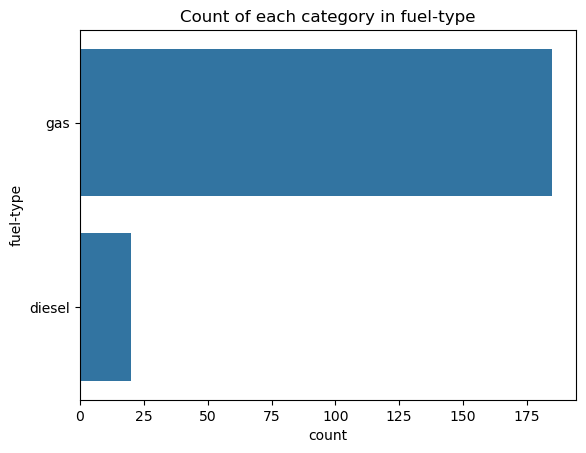

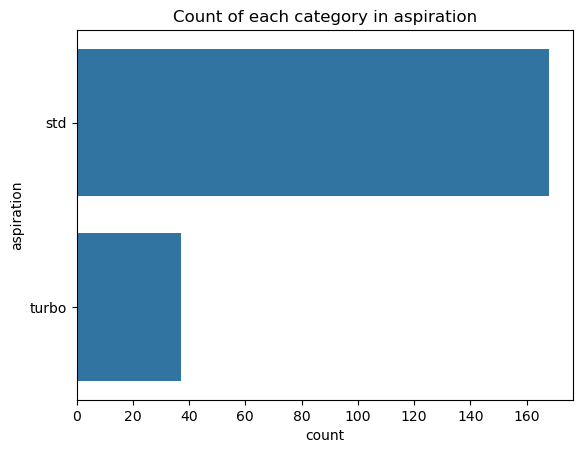

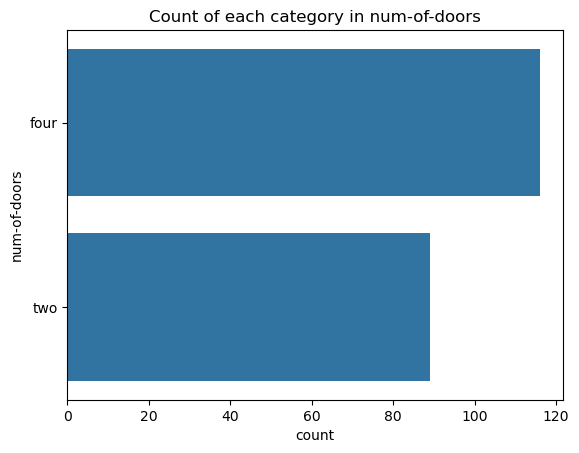

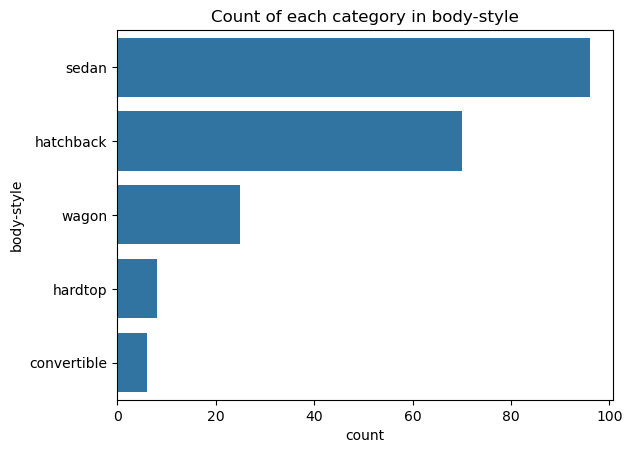

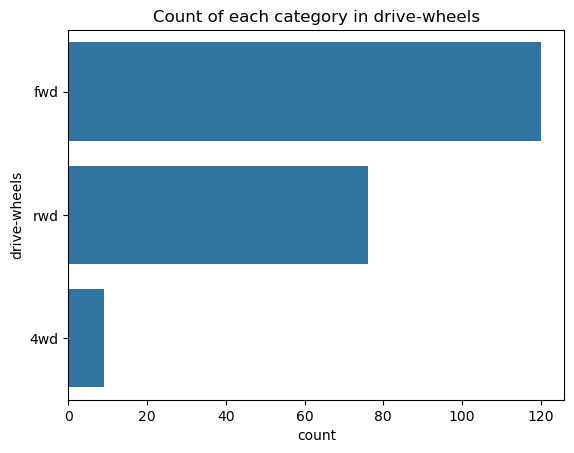

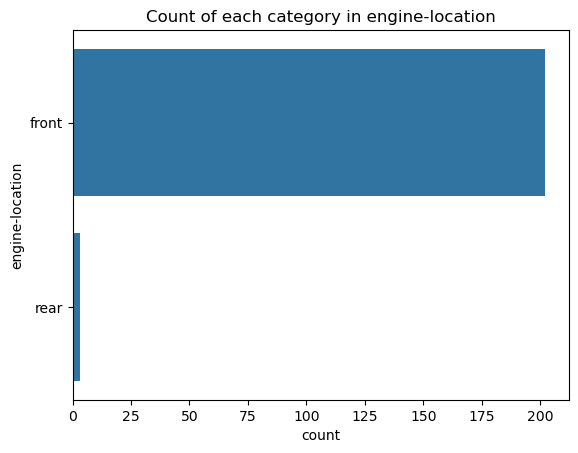

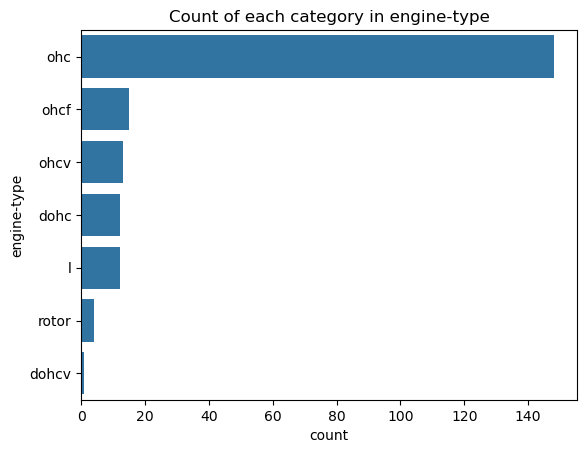

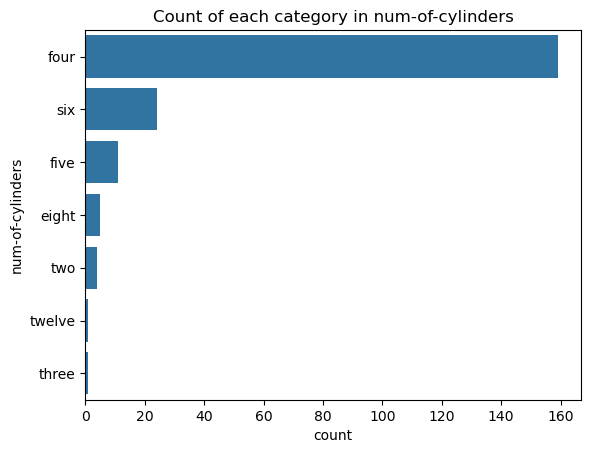

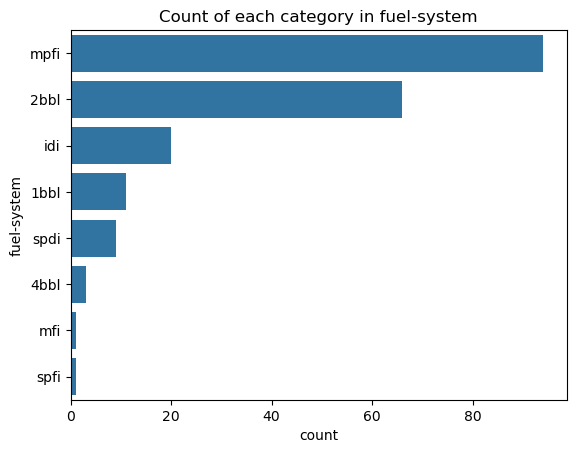

In [266]:
for col in Ncategorical_cols:
    sns.countplot(y=df[col], order=df[col].value_counts().index)
    plt.title(f"Count of each category in {col}")
    plt.show()


<Axes: xlabel='price'>

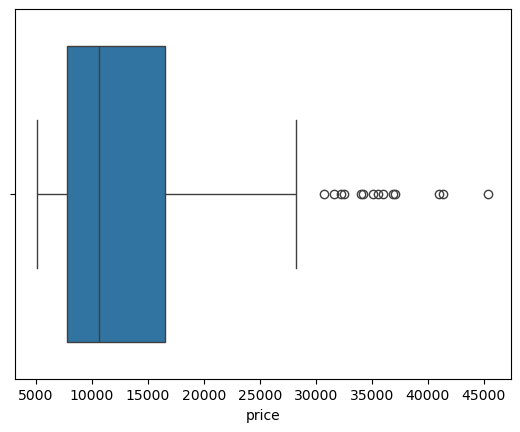

In [267]:
sns.boxplot(data=df, x='price')

# Bivariate
* Numeric vs Numeric: Correlation and Scatterplots
* Categorical vs Numeric: Boxplots, ANOVA
* Categorical vs Categorical: Cross-tabulations, stacked bars

Text(0.5, 1.0, 'Correlation Matrix')

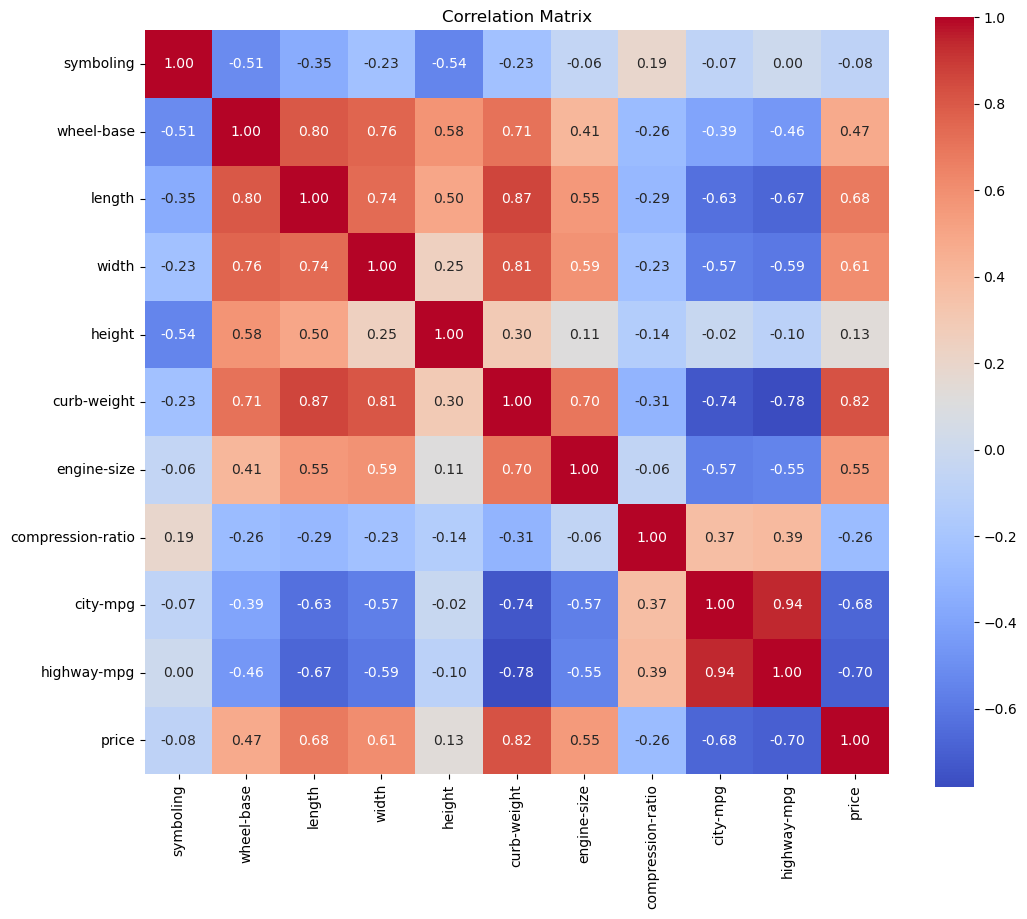

In [273]:
# Numeric vs Numeric: Correlation
corr_matrix = df.select_dtypes(include=[np.number]).corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', square=True)
plt.title('Correlation Matrix')

In [ ]:
# Feature Selection based on Correlation with target variable 'price'
# We can identify features that have a strong correlation with the target variable 'price'.
corr_matrix['price'].sort_values(ascending=False)

price                1.000000
curb-weight          0.820807
length               0.681529
width                0.610044
engine-size          0.549515
wheel-base           0.474090
height               0.133761
symboling           -0.082396
compression-ratio   -0.260291
city-mpg            -0.675362
highway-mpg         -0.701488
Name: price, dtype: float64

<Axes: xlabel='hw', ylabel='price'>

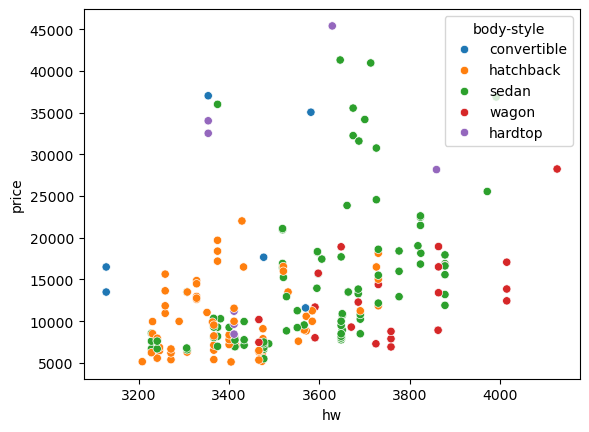

In [277]:
df['hw'] = df['height'] * df['width']
sns.scatterplot(x='hw', y='price', data=df, hue='body-style')


In [292]:
getDummy = pd.get_dummies(df['drive-wheels'], prefix='drive_wheels')
df = pd.concat([df, getDummy], axis=1)
df.head()

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,drive-wheels_rwd,drive-wheels_4wd,drive-wheels_fwd,drive-wheels_rwd,drive-wheels_4wd,drive-wheels_fwd,drive-wheels_rwd,drive_wheels_4wd,drive_wheels_fwd,drive_wheels_rwd
0,3,161,alfa_romero,gas,std,two,convertible,rwd,front,88.6,...,1.0,0.0,0.0,1.0,0.0,0.0,1.0,False,False,True
1,3,161,alfa_romero,gas,std,two,convertible,rwd,front,88.6,...,1.0,0.0,0.0,1.0,0.0,0.0,1.0,False,False,True
2,1,161,alfa_romero,gas,std,two,hatchback,rwd,front,94.5,...,1.0,0.0,0.0,1.0,0.0,0.0,1.0,False,False,True
3,2,164,audi,gas,std,four,sedan,fwd,front,99.8,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,False,True,False
4,2,164,audi,gas,std,four,sedan,4wd,front,99.4,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,True,False,False


In [291]:
from sklearn.preprocessing import OneHotEncoder

One = OneHotEncoder(sparse_output=False)
encoded = One.fit_transform(df[['drive-wheels']])
encoded_cols = One.get_feature_names_out(['drive-wheels'])
encoded_df = pd.DataFrame(encoded, columns=encoded_cols, index=df.index)

df = pd.concat([df, encoded_df], axis=1)
df.head()


,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,hw,drive-wheels_4wd,drive-wheels_fwd,drive-wheels_rwd,drive-wheels_4wd,drive-wheels_fwd,drive-wheels_rwd,drive-wheels_4wd,drive-wheels_fwd,drive-wheels_rwd
0,3,161,alfa_romero,gas,std,two,convertible,rwd,front,88.6,...,3128.08,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0
1,3,161,alfa_romero,gas,std,two,convertible,rwd,front,88.6,...,3128.08,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0
2,1,161,alfa_romero,gas,std,two,hatchback,rwd,front,94.5,...,3432.20,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0
3,2,164,audi,gas,std,four,sedan,fwd,front,99.8,...,3594.66,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
4,2,164,audi,gas,std,four,sedan,4wd,front,99.4,...,3605.52,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
